05_interpretation_business_recommendation.ipynb

Task-5 Model interpretation & Business Recommendations

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

In [92]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (2).csv


In [93]:
import pandas as pd

df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [94]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop wrong column (VERY IMPORTANT)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert TotalCharges safely
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df = df.dropna()

In [95]:
# Convert target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [96]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split done")

Data split done


In [97]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [98]:
# Initialize SHAP
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Enable visualization
shap.initjs()

shap summary plot

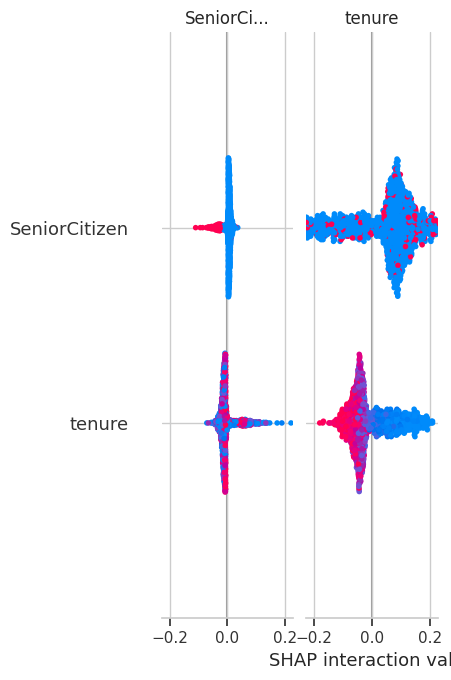

In [99]:
shap.summary_plot(shap_values, X_test)

SHAP Bar plot

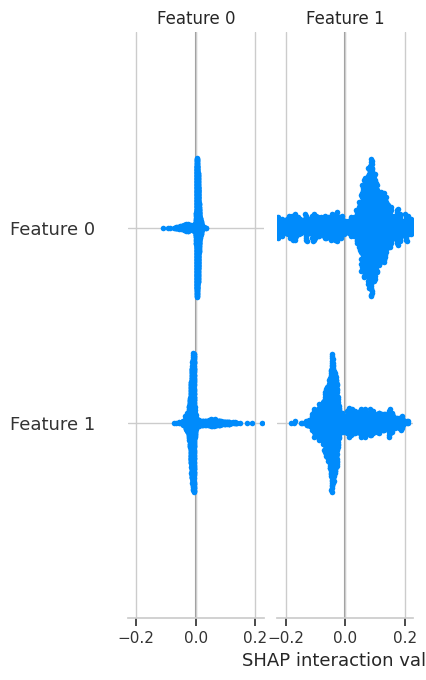

In [100]:
shap.summary_plot(shap_values, plot_type="bar")

local explanation

In [101]:
# pick 1 churned and 1 retained
churned_idx = y_test[y_test == 1].index[0]
retained_idx = y_test[y_test == 0].index[0]

# convert to position
c_pos = X_test.index.get_loc(churned_idx)
r_pos = X_test.index.get_loc(retained_idx)

In [102]:
explainer = shap.Explainer(best_model['Model_obj'], X_train)

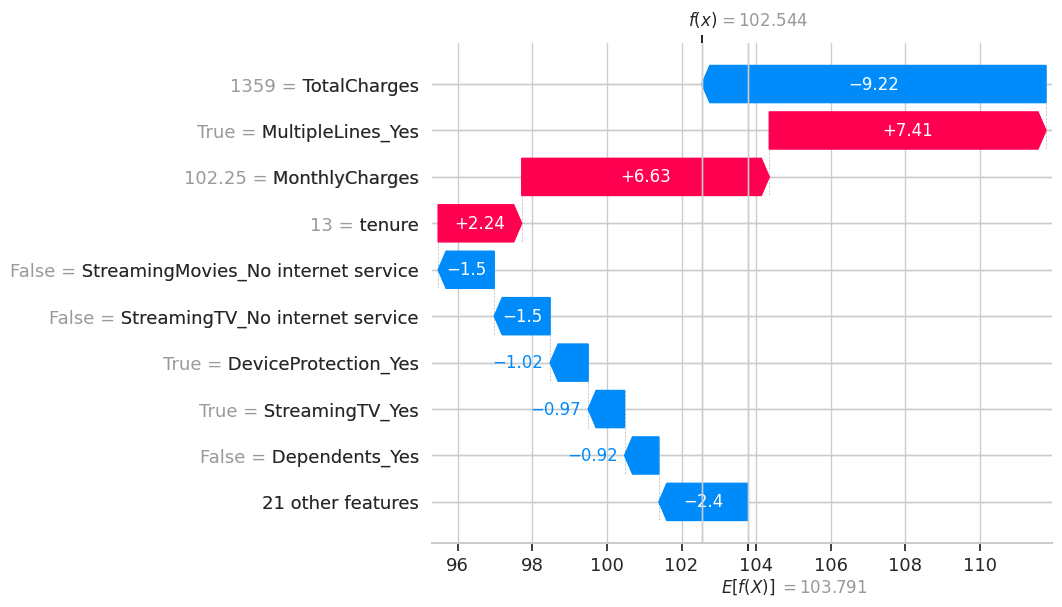

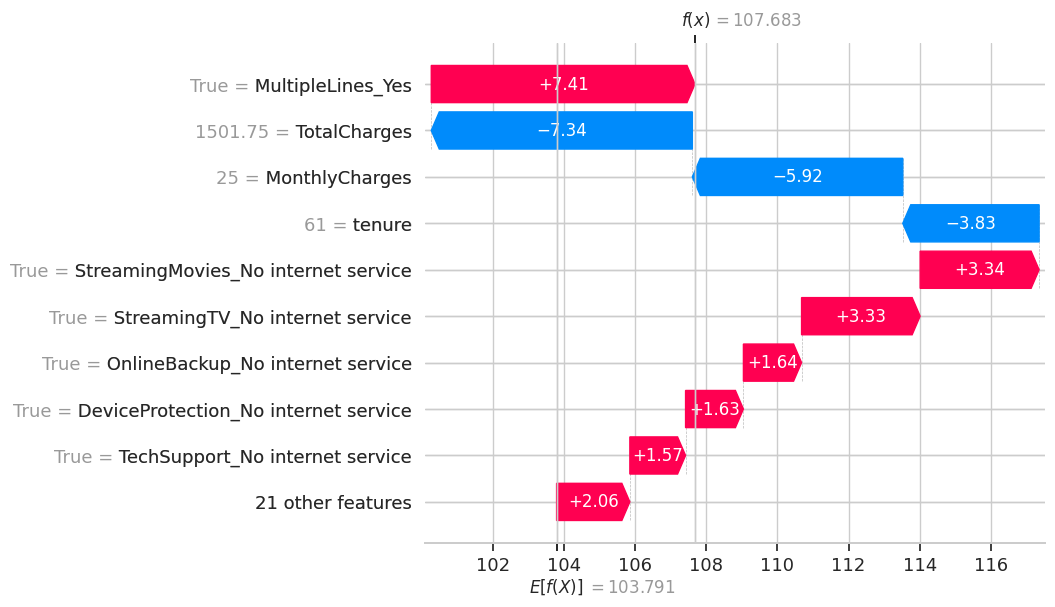

In [103]:
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[c_pos])
shap.plots.waterfall(shap_values[r_pos])

churned - features increasing risk ,
Retained- features reducing risk




In [104]:
import pandas as pd

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

top_features = feat_imp.head(3).index.tolist()
print("Top 3 features:", top_features)

Top 3 features: ['TotalCharges', 'MonthlyCharges', 'tenure']


Using features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warning

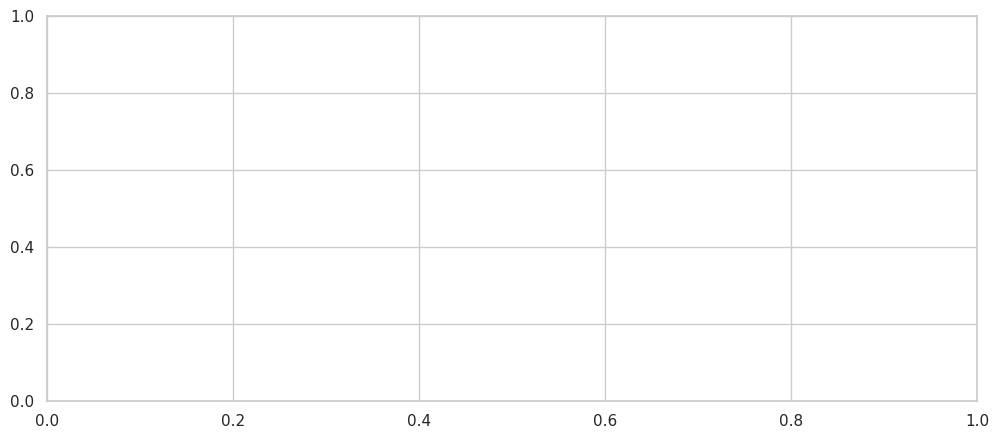

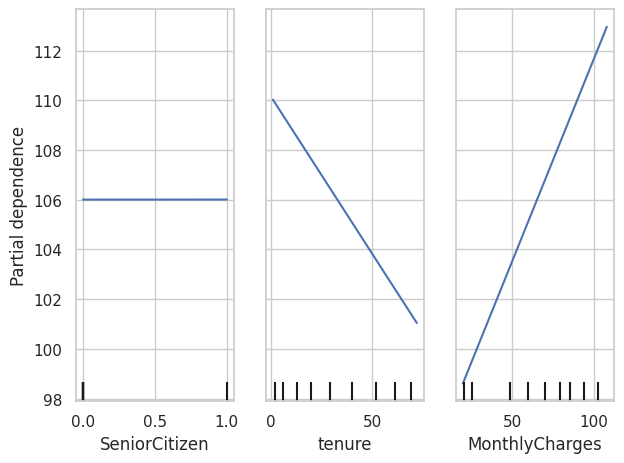

In [105]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt


try:
    model_used = best_model['Model_obj']
except:
    model_used = model


numeric_features = X_test.select_dtypes(include=['int64', 'float64']).columns
top_features = list(numeric_features[:3])

print("Using features:", top_features)


fig, ax = plt.subplots(figsize=(12, 5))

PartialDependenceDisplay.from_estimator(
    model_used,
    X_test,
    features=top_features,
    kind="average"

)

plt.tight_layout()
plt.show()

In [106]:
from sklearn.ensemble import RandomForestClassifier

best_clf_model = RandomForestClassifier()
best_clf_model.fit(X_train, y_train)

RandomForestClassifier()

In [107]:
print(X_train.shape)
print(type(X_train))

(5625, 30)
<class 'pandas.core.frame.DataFrame'>


answers for the business questions
Top 5 factors driving customer churn
Based on SHAP summary (global importance), the key drivers are:
Monthly Charges – Higher charges increase churn risk
Tenure – New customers churn more than long-term ones
Contract Type – Month-to-month customers churn the most
Total Charges – Lower total spend indicates weak engagement
Internet Service / Add-ons – Lack of bundled services increases churn
 Conclusion:
Customers who are new, paying more, and not locked into contracts are most likely to churn.

2.High-risk customer segments
From SHAP + model patterns:
Customers with month-to-month contracts
Low tenure (0–12 months)
High monthly charges
Customers without add-on services (TechSupport, OnlineSecurity)
Customers with fiber internet (higher cost plans)
 Conclusion:
High-risk customers are new, high-paying, low-commitment users without service bundles.

3.Pricing strategy recommendation
Based on regression + feature impact:
High monthly charges → higher churn
Long-term contracts → lower churn
Offer discounts for long-term contracts (1–2 years)
Introduce bundled packages (internet + support services)
Provide loyalty pricing for long-tenure customers
Give early-stage discounts (first 3–6 months)
 Conclusion:
Shift customers from high-cost monthly plans → discounted long-term bundles

If targeting only 100 customers
Select:
Top 100 customers with highest churn probability (model output)
Prioritize:
High monthly charges
Low tenure
Month-to-month contracts
 Why:
These customers give maximum ROI impact
They are most likely to churn but still recoverable

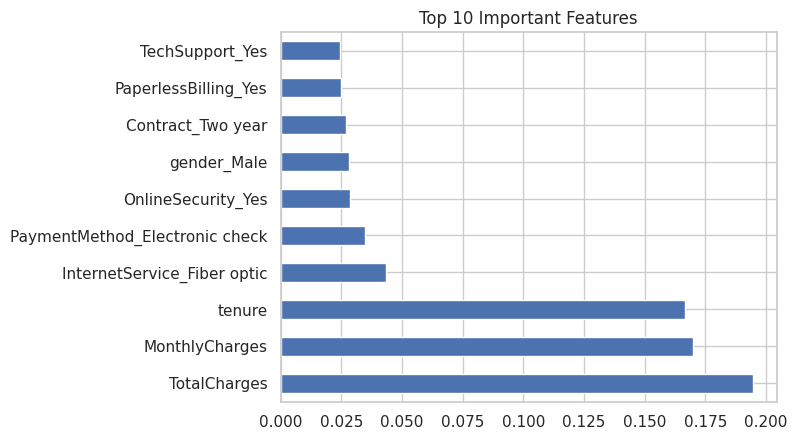

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_clf_model.feature_importances_
features = X_train.columns

imp_df = pd.Series(importances, index=features).sort_values(ascending=False)

# Top 10 features
imp_df.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

The Random Forest model identifies the most important features influencing the prediction.
From the feature importance plot, we can observe that the top features significantly impact the model's decision-making.

These features contribute the most to predicting the target variable, helping in understanding key drivers behind customer churn

In [109]:

# ROI CALCULATION - TASK 5


import pandas as pd
import numpy as np


y_pred_proba = model.predict_proba(X_test)[:, 1]


df = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_pred_proba
})


df = df.sort_values(by="Probability", ascending=False)


top_100 = df.head(100)


churners_model = top_100["Actual"].sum()


cost_per_customer = 50
loss_per_churn = 500


benefit_model = churners_model * loss_per_churn
cost_model = 100 * cost_per_customer

roi_model = (benefit_model - cost_model) / cost_model


# RANDOM TARGETING


random_100 = df.sample(100, random_state=42)
churners_random = random_100["Actual"].sum()

benefit_random = churners_random * loss_per_churn
cost_random = 100 * cost_per_customer

roi_random = (benefit_random - cost_random) / cost_random



print("===== ROI RESULTS =====")
print("Model Churners Captured:", churners_model)
print("Random Churners Captured:", churners_random)

print("\nModel ROI:", round(roi_model, 2))
print("Random ROI:", round(roi_random, 2))

print("\nImprovement:", round(roi_model / roi_random, 2), "times better")

===== ROI RESULTS =====
Model Churners Captured: 76
Random Churners Captured: 30

Model ROI: 6.6
Random ROI: 2.0

Improvement: 3.3 times better


## Business Insights

- High monthly charges → higher churn
- Long tenure → lower churn

## Recommendations

- Provide offers for high-paying users
- Improve onboarding for new customers